In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import wandb
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import os
import timm
from torch.optim.lr_scheduler import StepLR

In [2]:
batch_size = 32
img_height = 224
img_width = 224
train_path='C:\\Users\\Dell\\Desktop\\Courses\\Sem_VIII\\DA6401\\DA6401-Introduction-to-Deep-Learning\\Assignment_2\\inaturalist_12K\\train'

In [2]:
!wget https://storage.googleapis.com/wandb_datasets/nature_12K.zip
!unzip nature_12K.zip
!rm nature_12K.zip

--2025-04-18 22:57:13--  https://storage.googleapis.com/wandb_datasets/nature_12K.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.216.207, 108.177.12.207, 173.194.212.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.216.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3816687935 (3.6G) [application/zip]
Saving to: ‘nature_12K.zip’

nature_12K.zip      100%[===================>]   3.55G   149MB/s    in 22s     

2025-04-18 22:57:36 (166 MB/s) - ‘nature_12K.zip’ saved [3816687935/3816687935]

Archive:  nature_12K.zip
   creating: inaturalist_12K/
  inflating: inaturalist_12K/.DS_Store  
   creating: inaturalist_12K/train/
   creating: inaturalist_12K/train/Plantae/
  inflating: inaturalist_12K/train/Plantae/1dfc3916ad58af6ce9af9fc8b36ceedd.jpg  
  inflating: inaturalist_12K/train/Plantae/e49eeff2b27ae74351fdf8ffa3791307.jpg  
  inflating: inaturalist_12K/train/Plantae/519ae1c558dff337bb4084934e31a4a8.jpg 

In [3]:
# WandB initialization
wandb.login()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: anshul_2010 (anshul_2010-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [73]:
sweep_config = {
    'method': 'bayes',
    'metric': {
      'name': 'model_accuracy',
      'goal': 'maximize'   
    },
    'parameters': {
        'base': {
            'values': ['resnet', 'inception', 'mobilenet', 'inceptionresnet']
        },
        'in_epoch': {
            'values': [3, 5, 10]
        },
        'ft_epoch': {
            'values': [4, 6, 10]
        },
        'ft_bool': {
            'values': ['Yes','No']
        },
        'dropout': {
            'values': [0.1,0.2]
        },
        'learning_rate': {
            'values': [0.001,0.0001]
        },
        'optimizer_fn': {
            'values': ['Adam']
        },
        'activation_fn': {
            'values': ['relu','tanh']
        },
        'dense': {
            'values': [256,512]
        }
    }
}

In [54]:
# Data Preparation with PyTorch DataLoader
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

transform_valid = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(root=train_path, transform=transform_train)
valid_dataset = datasets.ImageFolder(root=train_path, transform=transform_valid)

train_size = int(0.8 * len(train_dataset))
valid_size = len(train_dataset) - train_size
train_subset, valid_subset = random_split(train_dataset, [train_size, valid_size])

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_subset, batch_size=batch_size, shuffle=False)

In [55]:
class_names = train_dataset.classes
print(class_names)

['Amphibia', 'Animalia', 'Arachnida', 'Aves', 'Fungi', 'Insecta', 'Mammalia', 'Mollusca', 'Plantae', 'Reptilia']


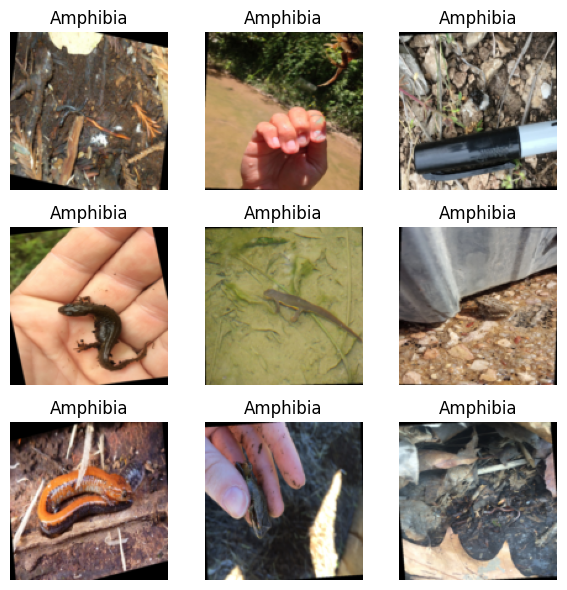

In [ ]:
# Access class names
class_names = train_dataset.classes

# Plot first 9 images
plt.figure(figsize=(6, 6))
for i in range(9):
    image, label = train_dataset[i]  # get image and label from Subset
    image = image.permute(1, 2, 0)  # [C, H, W] -> [H, W, C]
    
    # Unnormalize (ImageNet stats)
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    image = image * std + mean
    image = image.clamp(0, 1)

    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [56]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [57]:
# Load pretrained model
def get_model(base_name, num_classes):
    if base_name == 'resnet':
        model = models.resnet50(pretrained=True)
        num_ftrs = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(num_ftrs, num_classes)
        )
    elif base_name == 'mobilenet':
        model = models.mobilenet_v2(pretrained=True)
        num_ftrs = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(num_ftrs, num_classes)
        )
    elif base_name == 'inception':
        model = models.inception_v3(pretrained=True, aux_logits=True)
        num_ftrs = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(num_ftrs, num_classes)
        )
    elif base_name == 'inceptionresnet':
        model = timm.create_model('inception_resnet_v2', pretrained=True, num_classes=num_classes)
    else:
        model = timm.create_model('xception', pretrained=True, num_classes=num_classes)
    
    return model.to(device)

In [65]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs, ft_start=0, scheduler=None):
    history = {'acc': [], 'val_acc': [], 'loss': [], 'val_loss': []}
    for epoch in range(num_epochs):
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = dataloaders[0]
            else:
                model.eval()
                dataloader = dataloaders[1]
                
            running_loss, running_corrects = 0.0, 0

            for inputs, labels in tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs} [{phase}]"):
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    
                    # For InceptionV3, outputs are in InceptionOutputs, so we need to get the logits
                    if isinstance(outputs, tuple):  # Check if it's an InceptionOutputs tuple
                        outputs = outputs[0]  # Get the logits from the tuple
                    
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)
            
            wandb.log({f"{phase}_loss": epoch_loss, f"{phase}_acc": epoch_acc})
            history[f"{'' if phase == 'train' else 'val_'}loss"].append(epoch_loss)
            history[f"{'' if phase == 'train' else 'val_'}acc"].append(epoch_acc)

        if scheduler:
            scheduler.step()
    return history

In [74]:
# Main function for sweep
def main():
    wandb.init(project="DA6401-Assignment-2")
    config = wandb.config
    num_classes = 10

    model = get_model(config.base, num_classes)
    
    # Freeze all parameters first
    for name, param in model.named_parameters():
        param.requires_grad = False

    # Then selectively unfreeze classifier layers
    for name, param in model.named_parameters():
        if 'fc' in name or 'classifier' in name:
            param.requires_grad = True
            
    # Data Preparation with PyTorch DataLoader
    if config.base == 'inception' or config.base == 'inceptionresnet':
        image_size = (299, 299)  # Inception and InceptionResNet require 299x299
    else:
        image_size = (224, 224)  # Default size for other models

    transform_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    transform_valid = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    train_dataset = datasets.ImageFolder(root=train_path, transform=transform_train)
    valid_dataset = datasets.ImageFolder(root=train_path, transform=transform_valid)

    train_size = int(0.8 * len(train_dataset))
    valid_size = len(train_dataset) - train_size
    train_subset, valid_subset = random_split(train_dataset, [train_size, valid_size])

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_subset, batch_size=batch_size, shuffle=False)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = getattr(optim, config.optimizer_fn)(filter(lambda p: p.requires_grad, model.parameters()), lr=config.learning_rate)

    print("Training frozen base...")
    train_model(model, [train_loader, valid_loader], criterion, optimizer, 5)

    if config.ft_bool == 'Yes':
        print("Fine-tuning model...")
        # Unfreeze last few layers
        child_counter = 0
        for child in model.children():
            child_counter += 1
            if child_counter > 5:  # unfreeze last blocks
                for param in child.parameters():
                    param.requires_grad = True

        optimizer = getattr(optim, config.optimizer_fn)(filter(lambda p: p.requires_grad, model.parameters()), lr=config.learning_rate / 10)
        scheduler = StepLR(optimizer, step_size=3, gamma=0.1)

        train_model(model, [train_loader, valid_loader], criterion, optimizer, 10, scheduler=scheduler)

In [75]:
sweep_id = wandb.sweep(sweep_config, project="DA6401-Assignment-2", entity="anshul_2010-indian-institute-of-technology-madras")

Create sweep with ID: 3fx31x59
Sweep URL: https://wandb.ai/anshul_2010-indian-institute-of-technology-madras/DA6401-Assignment-2/sweeps/3fx31x59


In [ ]:
wandb.agent(sweep_id, function=main, count=1)

wandb: Agent Starting Run: ehlucfgb with config:
wandb: 	activation_fn: tanh
wandb: 	base: resnet
wandb: 	dense: 256
wandb: 	dropout: 0.1
wandb: 	ft_bool: Yes
wandb: 	ft_epoch: 6
wandb: 	in_epoch: 10
wandb: 	learning_rate: 0.0001
wandb: 	optimizer_fn: Adam


c:\Users\Dell\anaconda3\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training frozen base...


Epoch 1/5 [train]:  53%|█████▎    | 133/250 [34:12<27:54, 14.31s/it] 

In [ ]:
wandb.agent(sweep_id, function=main, project="DA6401-Assignment-2", count=50)

wandb: Agent Starting Run: b3r7yshj with config:
wandb: 	activation_fn: relu
wandb: 	base: inceptionresnet
wandb: 	dense: 512
wandb: 	dropout: 0.2
wandb: 	ft_bool: Yes
wandb: 	ft_epoch: 4
wandb: 	in_epoch: 10
wandb: 	learning_rate: 0.0001
wandb: 	optimizer_fn: adam


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/nn.py:635: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(
I0000 00:00:1745017510.964558     109 cuda_dnn.cc:529] Loaded cuDNN version 90300


282/282 ━━━━━━━━━━━━━━━━━━━━ 107s 265ms/step - accuracy: 0.5582 - loss: 1.3887 - val_accuracy: 0.7608 - val_loss: 0.7488
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 66s 234ms/step - accuracy: 0.7483 - loss: 0.8200 - val_accuracy: 0.7798 - val_loss: 0.7078
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 66s 232ms/step - accuracy: 0.7620 - loss: 0.7524 - val_accuracy: 0.7848 - val_loss: 0.6892
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 65s 232ms/step - accuracy: 0.7676 - loss: 0.7286 - val_accuracy: 0.7878 - val_loss: 0.6632
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 66s 233ms/step - accuracy: 0.7751 - loss: 0.7005 - val_accuracy: 0.7908 - val_loss: 0.6691
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 66s 233ms/step - accuracy: 0.7767 - loss: 0.6830 - val_accuracy: 0.7928 - val_loss: 0.6832
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 66s 233ms/step - accuracy: 0.7802 - loss: 0.6526 - val_accuracy: 0.7908 - val_loss: 0.6649
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 65s 232ms/step - accuracy: 0.7903 - loss: 0.6296 - va

...

wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: tp97qzjw with config:
wandb: 	activation_fn: tanh
wandb: 	base: inceptionresnet
wandb: 	dense: 512
wandb: 	dropout: 0.2
wandb: 	ft_bool: Yes
wandb: 	ft_epoch: 6
wandb: 	in_epoch: 10
wandb: 	learning_rate: 0.0001
wandb: 	optimizer_fn: adam


Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 105s 272ms/step - accuracy: 0.6013 - loss: 1.2518 - val_accuracy: 0.7988 - val_loss: 0.6691
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 67s 236ms/step - accuracy: 0.7791 - loss: 0.6733 - val_accuracy: 0.8018 - val_loss: 0.6392
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 65s 232ms/step - accuracy: 0.7888 - loss: 0.6275 - val_accuracy: 0.8038 - val_loss: 0.6280
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 65s 232ms/step - accuracy: 0.7972 - loss: 0.5965 - val_accuracy: 0.8018 - val_loss: 0.6298
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 66s 233ms/step - accuracy: 0.8162 - loss: 0.5703 - val_accuracy: 0.8048 - val_loss: 0.6285
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 66s 233ms/step - accuracy: 0.8113 - loss: 0.5538 - val_accuracy: 0.8078 - val_loss: 0.6289
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 66s 232ms/step - accuracy: 0.8161 - loss: 0.5467 - val_accuracy: 0.8028 - val_loss: 0.6361
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 66s 232ms/step - accuracy: 0.8195 - loss: 

accuracy,▁▅▅▆▆▆▆▇▇▇▇▇████
loss,█▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁
model_accuracy,▁
val_accuracy,▂▄▅▄▅▇▄▄▁▄▆▆▇▇▆█
val_loss,█▃▁▁▁▁▂▃▃▄▂▂▂▂▂▂
accuracy,0.84956
loss,0.44805
model_accuracy,0.81081
val_accuracy,0.81081
val_loss,0.6338


wandb: Agent Starting Run: o433hpgu with config:
wandb: 	activation_fn: tanh
wandb: 	base: inceptionresnet
wandb: 	dense: 512
wandb: 	dropout: 0.2
wandb: 	ft_bool: Yes
wandb: 	ft_epoch: 4
wandb: 	in_epoch: 10
wandb: 	learning_rate: 0.0001
wandb: 	optimizer_fn: sgd


Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 104s 261ms/step - accuracy: 0.6057 - loss: 1.2557 - val_accuracy: 0.7868 - val_loss: 0.6609
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 66s 235ms/step - accuracy: 0.7829 - loss: 0.6597 - val_accuracy: 0.7938 - val_loss: 0.6291
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 65s 231ms/step - accuracy: 0.8080 - loss: 0.5910 - val_accuracy: 0.8068 - val_loss: 0.6220
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 66s 232ms/step - accuracy: 0.8138 - loss: 0.5640 - val_accuracy: 0.7958 - val_loss: 0.6261
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 66s 233ms/step - accuracy: 0.8210 - loss: 0.5249 - val_accuracy: 0.7998 - val_loss: 0.6288
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 66s 233ms/step - accuracy: 0.8284 - loss: 0.5112 - val_accuracy: 0.7988 - val_loss: 0.6457
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 66s 233ms/step - accuracy: 0.8346 - loss: 0.4953 - val_accuracy: 0.7928 - val_loss: 0.6583
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 66s 233ms/step - accuracy: 0.8330 - loss: 